In [1]:
import pandas as pd
df_index = pd.read_csv("indexing/index_20220213_curated.csv",index_col="full")

df_mpra3 = pd.read_csv("indexing/MPRA3_Contributor_20231108_unique_GeneName_BarcodeEnhancerPair.csv").drop_duplicates("enhancer_id")
df_mpra3[["enhancer_id","Type","RSID","Contributor","nearest_gene"]].to_csv("indexing/RSID_Contributor_nearestGene.csv",index=False)
df_mpra3 = pd.read_csv("indexing/RSID_Contributor_nearestGene.csv",index_col="enhancer_id")

df_index = pd.merge(df_index, df_mpra3,left_index=True,right_index=True,how="left")
df_index.to_csv("indexing/index_20240103_curated.csv")

In [ ]:
mkdir -p catlas_cCREs
cd catlas_cCREs

wget -r -np -nH --cut-dirs=4 \
  -R "index.html*" \
  https://catlas.org/catlasv1/humanbrain/data/cCREs/


In [ ]:
catlas_cCREs

In [ ]:
import os
import glob
import pandas as pd


PEAKS_DIR = "catlas_cCREs/peaks"


def read_bed_as_df(bed_path: str) -> pd.DataFrame:
    """
    Read a BED file into a DataFrame.
    - ignores UCSC track/browser lines and comments
    - keeps variable number of columns
    """
    rows = []
    with open(bed_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("#") or line.startswith("track") or line.startswith("browser"):
                continue
            rows.append(line.split("\t"))

    if len(rows) == 0:
        return pd.DataFrame()

    # create generic col names for variable-width bed
    ncol = max(len(r) for r in rows)
    cols = ["chr", "start", "end","cCRE_id","value"] 

    # pad shorter rows
    rows = [r + [None] * (ncol - len(r)) for r in rows]

    df = pd.DataFrame(rows, columns=cols)

    # enforce types for first 3 columns
    df["start"] = df["start"].astype(int)
    df["end"] = df["end"].astype(int)

    return df


def load_all_beds(peaks_dir: str) -> pd.DataFrame:
    bed_paths = sorted(glob.glob(os.path.join(peaks_dir, "*.bed")))
    if len(bed_paths) == 0:
        raise RuntimeError(f"No .bed files found in: {peaks_dir}")

    dfs = []
    for p in bed_paths:
        cell_type = os.path.basename(p).replace(".bed", "")
        df = read_bed_as_df(p)

        if df.empty:
            print(f"[WARN] empty bed file: {p}")
            continue

        df["cell_type"] = cell_type
        dfs.append(df)

        print(f"Loaded {cell_type}: {df.shape[0]} peaks")

    all_df = pd.concat(dfs, axis=0, ignore_index=True)
    return all_df


if __name__ == "__main__":
    all_peaks_df = load_all_beds(PEAKS_DIR)

    print(all_peaks_df.head())
    print("\nFinal shape:", all_peaks_df.shape)

    # save the combined per-cell-type peak table
    out_csv = os.path.join(PEAKS_DIR, "all_peaks_with_cell_type.csv")
    all_peaks_df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)


Loaded ACBGM: 26737 peaks
Loaded AMY: 93699 peaks
Loaded ASCNT: 78183 peaks
Loaded ASCNT_1: 58465 peaks
Loaded ASCNT_2: 56675 peaks
Loaded ASCNT_3: 53145 peaks
Loaded ASCT: 141935 peaks
Loaded ASCT_1: 108760 peaks
Loaded ASCT_2: 126230 peaks
Loaded ASCT_3: 119565 peaks
Loaded BFEXA: 39648 peaks
Loaded BNGA: 16635 peaks
Loaded CBGA: 18076 peaks
Loaded CBGRC: 91384 peaks
Loaded CBINH: 7 peaks
Loaded CHO: 9995 peaks
Loaded CNGA: 68707 peaks
Loaded CNGA_1: 44719 peaks
Loaded CNGA_2: 53415 peaks
Loaded CNMIX: 3793 peaks
Loaded COP: 73800 peaks
Loaded CT: 108570 peaks
Loaded CTXGA: 34692 peaks
Loaded CT_1: 103516 peaks
Loaded CT_2: 38775 peaks
Loaded D12NAC: 102446 peaks
Loaded D1CaB: 88467 peaks
Loaded D1Pu: 78244 peaks
Loaded D2CaB: 96563 peaks
Loaded D2Pu: 74362 peaks
Loaded EC: 852 peaks
Loaded ERC_1: 69775 peaks
Loaded ERC_2: 6595 peaks
Loaded ET: 10270 peaks
Loaded FOXP2: 49645 peaks
Loaded FOXP2_1: 38108 peaks
Loaded FOXP2_2: 15500 peaks
Loaded FOXP2_3: 26577 peaks
Loaded FOXP2_4: 171

In [ ]:
df_peaks = pd.read_csv("catlas_cCREs/peaks/all_peaks_with_cell_type.csv")

In [7]:
df_peaks

,chr,start,end,cCRE_id,value,cell_type
0,chr1,180570,181069,cCRE_2,65.884832,ACBGM
1,chr1,633780,634279,cCRE_7,90640.346231,ACBGM
2,chr1,778387,778886,cCRE_8,369.014168,ACBGM
3,chr1,827320,827819,cCRE_14,50.392152,ACBGM
4,chr1,904491,904990,cCRE_24,29.998877,ACBGM
...,...,...,...,...,...,...
9321909,chrY,19744477,19744976,cCRE_544579,145.821581,VIP_7
9321910,chrY,19744979,19745478,cCRE_544580,9.050959,VIP_7
9321911,chrY,20575335,20575834,cCRE_544619,389.287246,VIP_7
9321912,chrY,26319773,26320272,cCRE_544701,11.822681,VIP_7


In [ ]:
import os
import pandas as pd
import numpy as np
import pyranges as pr

INDEX_PATH = 'indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_2025914.csv' 

PEAKS_PATH = "catlas_cCREs/peaks/all_peaks_with_cell_type.csv"

OUTDIR = "catlas_cCREs/results_overlap_mpra"
os.makedirs(OUTDIR, exist_ok=True)

OUT_OVERLAP_LONG = os.path.join(OUTDIR, "snps_x_peaks_overlaps_long.csv")
OUT_MATRIX_WIDE  = os.path.join(OUTDIR, "snps_x_celltype_peak_matrix.csv")
OUT_MERGED       = os.path.join(OUTDIR, "df_index_with_peak_matrix.csv")

df_index = pd.read_csv(INDEX_PATH, low_memory=False)

# Drop duplicated rsID first (keep the first occurrence)
df_snps = df_index.drop_duplicates(subset=["rsID"], keep="first").copy()

# Make UCSC-style chromosome string
def to_ucsc_chr(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    s = s.replace("chr", "").replace("CHR", "")
    # common encodings
    if s in {"23", "X", "x"}:
        return "chrX"
    if s in {"24", "Y", "y"}:
        return "chrY"
    if s in {"25", "M", "m", "MT", "mt"}:
        return "chrM"
    return "chr" + s

df_snps["chr"] = df_snps["chr_number"].map(to_ucsc_chr)

# Ensure pos is integer (hg38 position is typically 1-based)
df_snps["pos_hg38"] = pd.to_numeric(df_snps["pos_hg38"], errors="coerce").astype("Int64")
df_snps = df_snps.dropna(subset=["chr", "pos_hg38"]).copy()

print("df_snps (unique rsID) shape:", df_snps.shape)
df_snps[["rsID", "chr_number", "chr", "pos_hg38"]].head()


df_snps (unique rsID) shape: (599, 201)


,rsID,chr_number,chr,pos_hg38
0,cg03073402,19,chr19,42423524
1,cg03169557,16,chr16,89532542
2,cg05030077,16,chr16,2205198
3,cg05066959,8,chr8,41661790
4,cg05228284,19,chr19,2720849


In [48]:
df_peaks = pd.read_csv(PEAKS_PATH)

# Expect columns: chr, start, end, cell_type (plus optional extra cols)
required = {"chr", "start", "end", "cell_type"}
missing = required - set(df_peaks.columns)
if missing:
    raise ValueError(f"Missing required columns in peaks CSV: {missing}")

df_peaks["start"] = pd.to_numeric(df_peaks["start"], errors="coerce").astype("Int64")
df_peaks["end"]   = pd.to_numeric(df_peaks["end"], errors="coerce").astype("Int64")
df_peaks = df_peaks.dropna(subset=["chr", "start", "end", "cell_type"]).copy()

print("df_peaks shape:", df_peaks.shape)
df_peaks.head()


df_peaks shape: (9321914, 6)


,chr,start,end,cCRE_id,value,cell_type
0,chr1,180570,181069,cCRE_2,65.884832,ACBGM
1,chr1,633780,634279,cCRE_7,90640.346231,ACBGM
2,chr1,778387,778886,cCRE_8,369.014168,ACBGM
3,chr1,827320,827819,cCRE_14,50.392152,ACBGM
4,chr1,904491,904990,cCRE_24,29.998877,ACBGM


In [49]:
# SNPs as 1-bp intervals in 0-based coordinates
snps_pr = pr.PyRanges(
    df_snps.assign(
        Start=(df_snps["pos_hg38"].astype(int) - 1),
        End=(df_snps["pos_hg38"].astype(int))
    )[["chr", "Start", "End", "rsID", "pos_hg38"]].rename(columns={"chr": "Chromosome"})
)

peaks_pr = pr.PyRanges(
    df_peaks.rename(columns={"chr": "Chromosome", "start": "Start", "end": "End"})
    [["Chromosome", "Start", "End", "cell_type"]]
)

# Overlap (join) SNP intervals with peak intervals
ov = snps_pr.join(peaks_pr)
ov_df = ov.df.copy()

# pyranges typically suffixes overlapping columns from the right with "_b"
# (so peaks Start/End become Start_b/End_b)
rename_map = {}
if "Start_b" in ov_df.columns: rename_map["Start_b"] = "peak_start"
if "End_b" in ov_df.columns:   rename_map["End_b"]   = "peak_end"
ov_df = ov_df.rename(columns=rename_map)

# Keep a clean long table
keep_cols = ["rsID", "Chromosome", "pos_hg38", "cell_type"]
if "peak_start" in ov_df.columns: keep_cols += ["peak_start"]
if "peak_end" in ov_df.columns:   keep_cols += ["peak_end"]

ov_long = ov_df[keep_cols].copy()
ov_long.to_csv(OUT_OVERLAP_LONG, index=False)

print("Overlaps (long) shape:", ov_long.shape)
print("Saved:", OUT_OVERLAP_LONG)
ov_long.head()


Overlaps (long) shape: (8628, 6)
Saved: /media/zihengc/T7/mpra3_lib_analysis/catlas_cCREs/results_overlap_mpra/snps_x_peaks_overlaps_long.csv


,rsID,Chromosome,pos_hg38,cell_type,peak_start,peak_end
0,rs115702818,chr1,101454018,CT,101453662,101454161
1,rs115702818,chr1,101454018,CT_1,101453662,101454161
2,rs115702818,chr1,101454018,CT_2,101453662,101454161
3,rs115702818,chr1,101454018,D1Pu,101453662,101454161
4,rs115702818,chr1,101454018,ITL23,101453662,101454161


In [50]:
# One row per (rsID, cell_type) indicating presence in at least one peak
mat = (
    ov_long[["rsID", "cell_type"]]
    .drop_duplicates()
    .assign(in_peak=1)
    .pivot_table(index="rsID", columns="cell_type", values="in_peak", aggfunc="max", fill_value=0)
    .astype(int)
)

# Include SNPs with zero overlaps (all zeros)
all_rsids = pd.Index(df_snps["rsID"].unique(), name="rsID")
mat = mat.reindex(all_rsids, fill_value=0)

mat.to_csv(OUT_MATRIX_WIDE)
print("Matrix shape:", mat.shape)
print("Saved:", OUT_MATRIX_WIDE)

mat.head()


Matrix shape: (599, 127)
Saved: /media/zihengc/T7/mpra3_lib_analysis/catlas_cCREs/results_overlap_mpra/snps_x_celltype_peak_matrix.csv


cell_type,ACBGM,AMY,ASCNT,ASCNT_1,ASCNT_2,ASCNT_3,ASCT,ASCT_1,ASCT_2,ASCT_3,...,THMGA_2,TP,VIP,VIP_1,VIP_2,VIP_3,VIP_4,VIP_5,VIP_6,VIP_7
rsID,,,,,,,,,,,,,,,,,,,,,
cg03073402,0,1,1,1,1,1,1,1,1,1,...,0,1,1,1,1,1,1,1,1,1
cg03169557,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
cg05030077,1,1,1,1,1,1,1,1,1,1,...,0,0,1,1,1,1,1,1,1,1
cg05066959,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
cg05228284,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [51]:
mat[mat.sum(axis=1)==0]

cell_type,ACBGM,AMY,ASCNT,ASCNT_1,ASCNT_2,ASCNT_3,ASCT,ASCT_1,ASCT_2,ASCT_3,...,THMGA_2,TP,VIP,VIP_1,VIP_2,VIP_3,VIP_4,VIP_5,VIP_6,VIP_7
rsID,,,,,,,,,,,,,,,,,,,,,
cg05066959,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
cg05228284,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
cg07571519,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
cg14761246,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
cg20618448,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rs9271608,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
rs9281938,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
rs9304646,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
# Set rsID as index for merge
df_snps_unique = df_snps.set_index("rsID")

# Join matrix columns; fill missing with 0
df_merged = df_snps_unique.join(mat, how="left").fillna(0)

df_merged.to_csv(OUT_MERGED, index=True)
print("Merged table shape:", df_merged.shape)
print("Saved:", OUT_MERGED)

df_merged.head()


Merged table shape: (599, 327)
Saved: /media/zihengc/T7/mpra3_lib_analysis/catlas_cCREs/results_overlap_mpra/df_index_with_peak_matrix.csv


,Unnamed: 0,RSID,Contributor,nearest_gene,chr_number,pos_hg38,ref,alt,AFR,AMR,...,THMGA_2,TP,VIP,VIP_1,VIP_2,VIP_3,VIP_4,VIP_5,VIP_6,VIP_7
rsID,,,,,,,,,,,,,,,,,,,,,
cg03073402,alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42...,cg03073402,Bertram,LIPE,19,42423524,0,0,0.0,0.0,...,0,1,1,1,1,1,1,1,1,1
cg03169557,alt:cg03169557:SNPCENTER:chr16:89598950:C:G:89...,cg03169557,Bertram,SPG7,16,89532542,0,0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
cg05030077,alt:cg05030077:SNPCENTER:chr16:2255199:C:G:225...,cg05030077,Bertram,MLST8,16,2205198,0,0,0.0,0.0,...,0,0,1,1,1,1,1,1,1,1
cg05066959,alt:cg05066959:SNPCENTER:chr8:41519308:C:G:415...,cg05066959,Bertram,ANK1,8,41661790,0,0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
cg05228284,alt:cg05228284:SNPCENTER:chr19:2720847:C:G:272...,cg05228284,Bertram,DIRAS1,19,2720849,0,0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import pandas as pd
import numpy as np

INDEX_PATH = "indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_2025914.csv"
PEAK_MAT_PATH = "catlas_cCREs/results_overlap_mpra/snps_x_celltype_peak_matrix.csv"
OUT_PATH = "indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_20260112.csv"

# 1) Read df_index, keeping its original index
df_index = pd.read_csv(INDEX_PATH, low_memory=False, index_col=0)
df_index["rsID"] = df_index["rsID"].astype(str)

# 2) Read the peak matrix
# snps_x_celltype_peak_matrix.csv usually has rsID in the first column (sometimes as the index) - handle both
df_peakmat = pd.read_csv(PEAK_MAT_PATH, low_memory=False)

if "rsID" not in df_peakmat.columns:
    # if rsID is the index column (first column), promote it to a named column
    df_peakmat = df_peakmat.rename(columns={df_peakmat.columns[0]: "rsID"})

df_peakmat["rsID"] = df_peakmat["rsID"].astype(str)

# drop duplicates to avoid row explosion on join
df_peakmat = df_peakmat.drop_duplicates(subset=["rsID"], keep="first")

# 3) Set rsID as the index to make the join easy
df_peakmat = df_peakmat.set_index("rsID")

# 4) Use join to preserve df_index's original index (no _orig_index suffix)
df_new_index = df_index.join(df_peakmat, on="rsID", how="left")

# 5) Fill missing peak-matrix values with 0 (only for the newly added peak columns)
peak_cols = df_peakmat.columns
df_new_index[peak_cols] = df_new_index[peak_cols].fillna(0)

# cast binary (0/1) columns to int8 to save memory
for c in peak_cols:
    uniq = set(pd.unique(df_new_index[c].dropna()))
    if uniq.issubset({0, 1}):
        df_new_index[c] = df_new_index[c].astype(np.int8)

# 6) Save: writes df_index's index back as the first CSV column (no extra _orig_index)
df_new_index.to_csv(OUT_PATH)
df_new_index


,RSID,Contributor,nearest_gene,rsID,chr_number,pos_hg38,ref,alt,AFR,AMR,...,THMGA_2,TP,VIP,VIP_1,VIP_2,VIP_3,VIP_4,VIP_5,VIP_6,VIP_7
alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42927563:42927789:42927676,cg03073402,Bertram,LIPE,cg03073402,19,42423524,NaN,NaN,NaN,NaN,...,0,1,1,1,1,1,1,1,1,1
alt:cg03169557:SNPCENTER:chr16:89598950:C:G:89598837:89599063:89598950,cg03169557,Bertram,SPG7,cg03169557,16,89532542,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
alt:cg05030077:SNPCENTER:chr16:2255199:C:G:2255086:2255312:2255199,cg05030077,Bertram,MLST8,cg05030077,16,2205198,NaN,NaN,NaN,NaN,...,0,0,1,1,1,1,1,1,1,1
alt:cg05066959:SNPCENTER:chr8:41519308:C:G:41519195:41519421:41519308,cg05066959,Bertram,ANK1,cg05066959,8,41661790,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
alt:cg05228284:SNPCENTER:chr19:2720847:C:G:2720734:2720960:2720847,cg05228284,Bertram,DIRAS1,cg05228284,19,2720849,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
alt:rs9478143:PEAKCENTER:chr6:150862035:A:G:150861632:150862271:150862051,rs9478143,Tanzi,MTHFD1L,rs9478143,6,150862035,A,G,0.79,0.51,...,0,0,0,0,0,0,0,0,0,0
alt:rs953471:PEAKCENTER:chr9:124221903:G:A:124221758:124221963:124221854,rs953471,Tanzi,NEK6,rs953471,9,124221903,G,A,0.04,0.15,...,0,0,0,0,0,0,0,0,0,0
alt:rs965034941:SNPCENTER:chr19:1999195:CCA:C:1999082:1999308:1999195,rs965034941,Tanzi,BTBD2,rs965034941,19,1999195,CCA,C,0.00,0.00,...,0,0,0,0,0,0,0,0,0,0
alt:rs983392:PEAKCENTER:chr11:59923508:A:G:59923333:59923833:59923583,rs983392,Pfenning,MS4A6A,rs983392,11,60156035,A,G,0.03,0.32,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_index=pd.read_csv('indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_20260112.csv',index_col=0)
df_index

,RSID,Contributor,nearest_gene,rsID,chr_number,pos_hg38,ref,alt,AFR,AMR,...,THMGA_2,TP,VIP,VIP_1,VIP_2,VIP_3,VIP_4,VIP_5,VIP_6,VIP_7
alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42927563:42927789:42927676,cg03073402,Bertram,LIPE,cg03073402,19,42423524,NaN,NaN,NaN,NaN,...,0,1,1,1,1,1,1,1,1,1
alt:cg03169557:SNPCENTER:chr16:89598950:C:G:89598837:89599063:89598950,cg03169557,Bertram,SPG7,cg03169557,16,89532542,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
alt:cg05030077:SNPCENTER:chr16:2255199:C:G:2255086:2255312:2255199,cg05030077,Bertram,MLST8,cg05030077,16,2205198,NaN,NaN,NaN,NaN,...,0,0,1,1,1,1,1,1,1,1
alt:cg05066959:SNPCENTER:chr8:41519308:C:G:41519195:41519421:41519308,cg05066959,Bertram,ANK1,cg05066959,8,41661790,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
alt:cg05228284:SNPCENTER:chr19:2720847:C:G:2720734:2720960:2720847,cg05228284,Bertram,DIRAS1,cg05228284,19,2720849,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
alt:rs9478143:PEAKCENTER:chr6:150862035:A:G:150861632:150862271:150862051,rs9478143,Tanzi,MTHFD1L,rs9478143,6,150862035,A,G,0.79,0.51,...,0,0,0,0,0,0,0,0,0,0
alt:rs953471:PEAKCENTER:chr9:124221903:G:A:124221758:124221963:124221854,rs953471,Tanzi,NEK6,rs953471,9,124221903,G,A,0.04,0.15,...,0,0,0,0,0,0,0,0,0,0
alt:rs965034941:SNPCENTER:chr19:1999195:CCA:C:1999082:1999308:1999195,rs965034941,Tanzi,BTBD2,rs965034941,19,1999195,CCA,C,0.00,0.00,...,0,0,0,0,0,0,0,0,0,0
alt:rs983392:PEAKCENTER:chr11:59923508:A:G:59923333:59923833:59923583,rs983392,Pfenning,MS4A6A,rs983392,11,60156035,A,G,0.03,0.32,...,0,0,0,0,0,0,0,0,0,0


In [86]:
df_index = df_index.set_index(['rsID']).drop_duplicates('RSID').iloc[:,-127:]
df_index

,ACBGM,AMY,ASCNT,ASCNT_1,ASCNT_2,ASCNT_3,ASCT,ASCT_1,ASCT_2,ASCT_3,...,THMGA_2,TP,VIP,VIP_1,VIP_2,VIP_3,VIP_4,VIP_5,VIP_6,VIP_7
rsID,,,,,,,,,,,,,,,,,,,,,
cg03073402,0,1,1,1,1,1,1,1,1,1,...,0,1,1,1,1,1,1,1,1,1
cg03169557,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
cg05030077,1,1,1,1,1,1,1,1,1,1,...,0,0,1,1,1,1,1,1,1,1
cg05066959,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
cg05228284,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rs9478143,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
rs953471,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
rs965034941,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_metadata = pd.read_csv('catlas_cCREs/metadata/bed_annotation.csv' )
df_metadata

,Cell class,Cell class name,Cell subclass,Cell subclass name,Cell type,Cell type name
0,GABA,GABAergic neurons,BFEXA,GABAergic neurons from basal forebrain and ext...,BFEXA,Inhibitory neurons from basal forebrain and ex...
1,GABA,GABAergic neurons,BNGA,GABAergic neurons from basal nuclei,BNGA,GABAergic neurons from basal nuclei
2,GABA,GABAergic neurons,CBGA,GABAergic-like neurons from cerebellum,PKJ_2,Purkinje cells - type 2
3,GABA,GABAergic neurons,CBGA,GABAergic-like neurons from cerebellum,PKJ_1,Purkinje cells - type 1
4,GABA,GABAergic neurons,CBGA,GABAergic-like neurons from cerebellum,CBINH,Inhibitory neurons from cerebellum
...,...,...,...,...,...,...
102,NonN,Non-neurons,OPC,Oligodendrocytes precursor cells,OPC,Oligodendrocytes precursor cells
103,NonN,Non-neurons,OPC,Oligodendrocytes precursor cells,COP,Committed oligodendrocytes cells
104,NonN,Non-neurons,PER,"Pericytes-like, too few nuclei",PER,"Pericytes-like, too few nuclei"
105,NonN,Non-neurons,PRERC,Glutamatergic neurons from piriform cortex and...,ERC_1,Glutamatergic neurons from entorhinal cortex -...


In [ ]:
import os
import gzip
import pandas as pd
import matplotlib.pyplot as plt


BED_DIR = "catlas_cCREs"
OUT_CSV = os.path.join(BED_DIR, "bed_peak_counts.csv")
OUT_FIG = os.path.join(BED_DIR, "bed_peak_counts_barplot.png")

# if there are too many files, only plot the top N (otherwise the x-axis gets overcrowded)
TOP_N = 40


def count_bed_lines(path: str) -> int:
    """
    Count peaks in a BED or BED.GZ file.
    - counts non-empty lines
    - ignores comments and UCSC track/browser lines
    """
    opener = gzip.open if path.endswith(".gz") else open
    n = 0
    with opener(path, "rt") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("#"):
                continue
            if line.startswith("track") or line.startswith("browser"):
                continue
            n += 1
    return n


def main():
    bed_files = []
    for fn in os.listdir(BED_DIR):
        if fn.endswith(".bed") or fn.endswith(".bed.gz"):
            bed_files.append(fn)

    bed_files = sorted(bed_files)

    if len(bed_files) == 0:
        raise RuntimeError(f"No .bed or .bed.gz files found in {BED_DIR}")

    results = []
    for fn in bed_files:
        path = os.path.join(BED_DIR, fn)
        n_peaks = count_bed_lines(path)
        results.append({"file": fn, "n_peaks": n_peaks})
        print(f"{fn}\t{n_peaks}")

    df = pd.DataFrame(results).sort_values("n_peaks", ascending=False)
    df.to_csv(OUT_CSV, index=False)
    print(f"\nSaved counts table: {OUT_CSV}")

    # ---- plot ----
    plot_df = df.copy()
    if len(plot_df) > TOP_N:
        plot_df = plot_df.head(TOP_N)

    # shorten labels a bit
    plot_df["label"] = plot_df["file"].str.replace(".bed.gz", "", regex=False).str.replace(".bed", "", regex=False)

    plt.figure(figsize=(max(12, 0.35 * len(plot_df)), 6))
    plt.bar(plot_df["label"], plot_df["n_peaks"])
    plt.xticks(rotation=75, ha="right", fontsize=8)
    plt.ylabel("Number of peaks (BED lines)")
    plt.title(f"Peak counts per BED file (Top {min(TOP_N, len(df))})")
    plt.tight_layout()
    plt.savefig(OUT_FIG, dpi=300)
    plt.close()
    print(f"Saved bar plot: {OUT_FIG}")


if __name__ == "__main__":
    main()


ACBGM.bed	26737
AMY.bed	93699
ASCNT.bed	78183
ASCNT_1.bed	58465
ASCNT_2.bed	56675
ASCNT_3.bed	53145
ASCT.bed	141935
ASCT_1.bed	108760
ASCT_2.bed	126230
ASCT_3.bed	119565
BFEXA.bed	39648
BNGA.bed	16635
CBGA.bed	18076
CBGRC.bed	91384
CBINH.bed	7
CHO.bed	9995
CNGA.bed	68707
CNGA_1.bed	44719
CNGA_2.bed	53415
CNMIX.bed	3793
COP.bed	73800
CT.bed	108570
CTXGA.bed	34692
CT_1.bed	103516
CT_2.bed	38775
D12NAC.bed	102446
D1CaB.bed	88467
D1Pu.bed	78244
D2CaB.bed	96563
D2Pu.bed	74362
EC.bed	852
ERC_1.bed	69775
ERC_2.bed	6595
ET.bed	10270
FOXP2.bed	49645
FOXP2_1.bed	38108
FOXP2_2.bed	15500
FOXP2_3.bed	26577
FOXP2_4.bed	17178
ICGA_1.bed	73
ICGA_2.bed	25461
ITL23.bed	219434
ITL23_1.bed	136188
ITL23_2.bed	148709
ITL23_3.bed	165951
ITL23_4.bed	154448
ITL23_5.bed	115271
ITL23_6.bed	145757
ITL34.bed	126220
ITL4.bed	132119
ITL45.bed	95260
ITL45_1.bed	93977
ITL45_2.bed	24400
ITL4_1.bed	111920
ITL4_2.bed	118266
ITL5.bed	166208
ITL5_1.bed	150690
ITL5_2.bed	103367
ITL5_3.bed	94471
ITL5_4.bed	54357
ITL6_1.bed	1

In [ ]:
# One-shot diagnostic + fix: find why some peak files aren't columns in snps_x_celltype_peak_matrix.csv
# and optionally write a "full" matrix that includes ALL peak files as columns (missing -> 0).

import os, glob
import pandas as pd
import numpy as np

PEAKS_DIR = "catlas_cCREs/peaks"
MAT_PATH  = "catlas_cCREs/results_overlap_mpra/snps_x_celltype_peak_matrix.csv"
ALL_PEAKS_PATH = os.path.join(PEAKS_DIR, "all_peaks_with_cell_type.csv")  # optional, if exists

OUT_FULL = MAT_PATH.replace(".csv", "_with_all_peakfiles.csv")

def strip_ext(fn: str) -> str:
    for ext in [".bed.gz", ".bed", ".narrowPeak.gz", ".narrowPeak", ".txt.gz", ".txt"]:
        if fn.endswith(ext):
            return fn[: -len(ext)]
    return os.path.splitext(fn)[0]

# 1) Collect expected column names from PEAKS_DIR (bed + common peak formats)
peak_paths = []
for pat in ["*.bed", "*.bed.gz", "*.narrowPeak", "*.narrowPeak.gz", "*.txt", "*.txt.gz"]:
    peak_paths += glob.glob(os.path.join(PEAKS_DIR, pat))
peak_paths = sorted(set(peak_paths))

expected = [strip_ext(os.path.basename(p)) for p in peak_paths]
expected_set = set(expected)

# Detect name collisions after stripping extensions (can cause columns to merge/overwrite)
vc = pd.Series(expected).value_counts()
collisions = vc[vc > 1]
print(f"[INFO] Peak files found: {len(peak_paths)}")
print(f"[INFO] Unique expected column names (after stripping ext): {len(expected_set)}")
print(f"[INFO] Name collisions after stripping ext: {len(collisions)}")
if len(collisions) > 0:
    print("[WARN] Colliding names (show up to 20):")
    print(collisions.head(20).to_dict())

# 2) Read matrix columns
df_mat = pd.read_csv(MAT_PATH, low_memory=False)
if "rsID" not in df_mat.columns:
    df_mat = df_mat.rename(columns={df_mat.columns[0]: "rsID"})
mat_cols = [c for c in df_mat.columns if c != "rsID" and not str(c).startswith("Unnamed")]
mat_colset = set(mat_cols)

missing_in_matrix = sorted(expected_set - mat_colset)
extra_in_matrix   = sorted(mat_colset - expected_set)

print(f"\n[INFO] Matrix columns (excluding rsID): {len(mat_cols)}")
print(f"[INFO] Missing columns (present as peak files but absent in matrix): {len(missing_in_matrix)}")
print(f"[INFO] Extra columns (in matrix but no matching peak file name): {len(extra_in_matrix)}")

if missing_in_matrix:
    print("\n[MISSING examples] (up to 50)")
    print(missing_in_matrix[:50])
if extra_in_matrix:
    print("\n[EXTRA examples] (up to 50)")
    print(extra_in_matrix[:50])

# 3) If all_peaks_with_cell_type.csv exists, decide whether missing are:
#    - not loaded into all_peaks (file reading issue), or
#    - loaded but had zero overlaps (pivot created no column)
if os.path.exists(ALL_PEAKS_PATH):
    df_all = pd.read_csv(ALL_PEAKS_PATH, low_memory=False)
    loaded_celltypes = set(df_all["cell_type"].astype(str).unique())

    missing_not_loaded = sorted(set(missing_in_matrix) - loaded_celltypes)
    missing_loaded_but_zero = sorted(set(missing_in_matrix) & loaded_celltypes)

    print(f"\n[INFO] all_peaks_with_cell_type.csv found: {ALL_PEAKS_PATH}")
    print(f"[INFO] Loaded cell_types in all_peaks: {len(loaded_celltypes)}")
    print(f"[DIAG] Missing because NOT loaded into all_peaks (read/format/path issue): {len(missing_not_loaded)}")
    if missing_not_loaded:
        print("  examples:", missing_not_loaded[:50])
    print(f"[DIAG] Missing but WAS loaded (likely ZERO SNP overlaps -> column dropped during pivot): {len(missing_loaded_but_zero)}")
    if missing_loaded_but_zero:
        print("  examples:", missing_loaded_but_zero[:50])
else:
    print(f"\n[INFO] all_peaks_with_cell_type.csv not found at {ALL_PEAKS_PATH} (skip read-vs-zero-overlap diagnosis).")

# 4) Fix: write a "full" matrix that includes ALL peak files as columns; missing filled with 0
df_mat = df_mat.set_index("rsID")
full_cols = sorted(expected_set)  # include every peak file name as a column
df_full = df_mat.reindex(columns=full_cols, fill_value=0)

# Ensure integer 0/1
df_full = (pd.to_numeric(df_full.stack(), errors="coerce").fillna(0).unstack() != 0).astype(np.int8)

df_full.to_csv(OUT_FULL)
print(f"\n[SAVED] Full matrix (all peak files as columns; missing->0): {OUT_FULL}")
print("[SAVED] Shape:", df_full.shape)


[INFO] Peak files found: 133
[INFO] Unique expected column names (after stripping ext): 133
[INFO] Name collisions after stripping ext: 0

[INFO] Matrix columns (excluding rsID): 127
[INFO] Missing columns (present as peak files but absent in matrix): 6
[INFO] Extra columns (in matrix but no matching peak file name): 0

[MISSING examples] (up to 50)
['CBINH', 'CNMIX', 'EC', 'ICGA_1', 'MDGA', 'PER']

[INFO] all_peaks_with_cell_type.csv found: /media/zihengc/T7/mpra3_lib_analysis/catlas_cCREs/peaks/all_peaks_with_cell_type.csv
[INFO] Loaded cell_types in all_peaks: 133
[DIAG] Missing because NOT loaded into all_peaks (read/format/path issue): 0
[DIAG] Missing but WAS loaded (likely ZERO SNP overlaps -> column dropped during pivot): 6
  examples: ['CBINH', 'CNMIX', 'EC', 'ICGA_1', 'MDGA', 'PER']

[SAVED] Full matrix (all peak files as columns; missing->0): /media/zihengc/T7/mpra3_lib_analysis/catlas_cCREs/results_overlap_mpra/snps_x_celltype_peak_matrix_with_all_peakfiles.csv
[SAVED] Shap

In [ ]:
import os
import pandas as pd
import numpy as np

# INPUTS
INDEX_PATH = "indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_2025914.csv"
MAT_PATH   = "catlas_cCREs/results_overlap_mpra/snps_x_celltype_peak_matrix_with_all_peakfiles.csv"

# OUTPUT (new file with matrix added)
OUT_PATH   = "indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_with_all_peakfiles_variant_category_20260310_Bellenguez_AD_direction.csv"

# 1) Read df_index, keep its original index (ref_index)
df_index = pd.read_csv(INDEX_PATH, low_memory=False, index_col=0)
df_index["rsID"] = df_index["rsID"].astype(str)

# 2) Read SNP×peakfile matrix (rsID + many 0/1 cols); keep rsID as key
df_mat = pd.read_csv(MAT_PATH, low_memory=False)

# Compatibility: rsID might be the first column (or written as index)
if "rsID" not in df_mat.columns:
    df_mat = df_mat.rename(columns={df_mat.columns[0]: "rsID"})

df_mat["rsID"] = df_mat["rsID"].astype(str)

# Drop duplicate rsID (avoid row explosion on join)
df_mat = df_mat.drop_duplicates(subset=["rsID"], keep="first").copy()

# 3) Use join to preserve df_index index; fill missing with 0
df_mat = df_mat.set_index("rsID")
df_out = df_index.join(df_mat, on="rsID", how="left")

new_cols = df_mat.columns.tolist()
df_out[new_cols] = df_out[new_cols].fillna(0)

# Cast 0/1 columns to int8 to save space
for c in new_cols:
    s = df_out[c]
    # only cast if it looks binary
    uniq = set(pd.unique(s.dropna()))
    if uniq.issubset({0, 1}):
        df_out[c] = s.astype(np.int8)

# 4) Save (keeps df_index index as first column)
df_out.to_csv(OUT_PATH)
print("Saved:", OUT_PATH)
print("Shape:", df_out.shape)

df_out.head()


Saved: /media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_with_all_peakfiles_20260112.csv
Shape: (855, 333)


,RSID,Contributor,nearest_gene,rsID,chr_number,pos_hg38,ref,alt,AFR,AMR,...,THMGA_2,TP,VIP,VIP_1,VIP_2,VIP_3,VIP_4,VIP_5,VIP_6,VIP_7
alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42927563:42927789:42927676,cg03073402,Bertram,LIPE,cg03073402,19,42423524,NaN,NaN,NaN,NaN,...,0,1,1,1,1,1,1,1,1,1
alt:cg03169557:SNPCENTER:chr16:89598950:C:G:89598837:89599063:89598950,cg03169557,Bertram,SPG7,cg03169557,16,89532542,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
alt:cg05030077:SNPCENTER:chr16:2255199:C:G:2255086:2255312:2255199,cg05030077,Bertram,MLST8,cg05030077,16,2205198,NaN,NaN,NaN,NaN,...,0,0,1,1,1,1,1,1,1,1
alt:cg05066959:SNPCENTER:chr8:41519308:C:G:41519195:41519421:41519308,cg05066959,Bertram,ANK1,cg05066959,8,41661790,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
alt:cg05228284:SNPCENTER:chr19:2720847:C:G:2720734:2720960:2720847,cg05228284,Bertram,DIRAS1,cg05228284,19,2720849,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


In [1]:
import os
import pandas as pd
import numpy as np

peripheral_immune = [
    "Encode_Monocyte_DHS_hg38.narrowPeak",
    "M2_IFNG.idr.optimal_peak.narrowPeak",
    "M2_NAIVE.idr.optimal_peak.narrowPeak",
    "THP1_IFNB_4hrs.idr.optimal_peak.narrowPeak",
    "THP1_IFNG_4hrs.idr.optimal_peak.narrowPeak",
    "THP1_LPSIFNG_4hrs.idr.optimal_peak.narrowPeak",
    "THP1_monocytes.idr.optimal_peak.narrowPeak",
    "THP1_Naive_4hrs.idr.optimal_peak.narrowPeak",
    "TLR4_IFNG.idr.optimal_peak.narrowPeak",
    "TLR4_IFNG_LPS.idr.optimal_peak.narrowPeak",
    "Alasoo_Macrophage_ATAC_hg38.bed",
]

central_immune = [
    "Gosselin_Microglia_ATAC_hg38.idr.optimal_peak.narrowPeak",
    "Kosoy_Microglia_OCRs_hg38.bed",
    "Corces_Microglia_sgATAC_hg38.idr.optimal.narrowPeak",
    "Mic.DUSP1.peak.annotation.txt",
    "Mic.P2RY12.peak.annotation.txt",
    "H1resting.idr.optimal_peak.narrowPeak",
    "H1stimulated.idr.optimal_peak.narrowPeak",
    "WTC11resting.idr.optimal_peak.narrowPeak",
    "WTC11stimulated.idr.optimal_peak.narrowPeak",
    "HMC3.idr.optimal_peak.narrowPeak",
]

blood_cells = [
    "mono_hg38.bed",
    "nk_hg38.bed",
    "cd4_hg38.bed",
    "cd8_hg38.bed",
    "B_cells_hg38.bed",
    "dendritic_hg38.bed",
    "basophil_hg38.bed",
    "progen_hg38.bed",
]

hek_cells = [
    "HEK293_ATAC_high_depth.idr.conservative_peak.narrowPeak",
    "HEK293T_ATAC.idr.conservative_peak.narrowPeak",
]

other = [

    "Ast.TPST1.peak.annotation.txt",
    "Exc.L6.CT.peak.annotation.txt",
    "Exc.L6b.peak.annotation.txt",
    "Ast.GRM3.peak.annotation.txt",
    "Exc.L5.6.RORB.LINC02196.peak.annotation.txt",
    "Exc.L6.THEMIS.NFIA.peak.annotation.txt",
    "Inh.L1.6.LAMP5.CA13.peak.annotation.txt",
    "Inh.L5.6.PVALB.STON2.peak.annotation.txt",
    "Exc.L2.3.CBLN2.LINC02306.peak.annotation.txt",
    "Inh.ENOX2.SPHKAP.peak.annotation.txt",
    "Inh.LAMP5.NRG1..Rosehip..peak.annotation.txt",
    "Exc.L3.5.RORB.PLCH1.peak.annotation.txt",
    "Ast.DPP10.peak.annotation.txt",
    "Inh.CUX2.MSR1.peak.annotation.txt",
    "Inh.GPC5.RIT2.peak.annotation.txt",
    "Inh.FBN2.EPB41L4A.peak.annotation.txt",
    "Inh.L3.5.SST.MAFB.peak.annotation.txt",
    "Inh.VIP.TSHZ2.peak.annotation.txt",
    "Exc.L4.5.RORB.GABRG1.peak.annotation.txt",
    "Inh.L5.6.SST.TH.peak.annotation.txt",
    "Exc.L4.5.RORB.IL1RAPL2.peak.annotation.txt",
    "Inh.PVALB.SULF1.peak.annotation.txt",
    "Inh.PVALB.CA8..Chandelier..peak.annotation.txt",
    "Inh.PVALB.HTR4.peak.annotation.txt",
    "Exc.L3.4.RORB.CUX2.peak.annotation.txt",
    "Inh.RYR3.TSHZ2.peak.annotation.txt",
    "Exc.L5.6.IT.Car3.peak.annotation.txt",
    "Inh.VIP.THSD7B.peak.annotation.txt",
    "Inh.ALCAM.TRPM3.peak.annotation.txt",
    "Opc.GRIA4.peak.annotation.txt",
    "Oli.OPALIN.peak.annotation.txt",
    "Opc.TPST1.peak.annotation.txt",
    "Oli.RASGRF1.peak.annotation.txt",
    "Exc.RELN.CHD7.peak.annotation.txt",
    "OPC.DOCK5.peak.annotation.txt",
]

df_out = pd.read_csv("indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_with_all_peakfiles_variant_category_20260310_Bellenguez_AD_direction.csv",index_col=0)
df_periphral = df_out.drop_duplicates('rsID').set_index('rsID')[peripheral_immune]
df_central = df_out.drop_duplicates('rsID').set_index('rsID')[central_immune]
df_blood = df_out.drop_duplicates('rsID').set_index('rsID')[blood_cells]
df_hek = df_out.drop_duplicates('rsID').set_index('rsID')[hek_cells]
df_other= df_out.drop_duplicates('rsID').set_index('rsID')[other]

import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

MAT_PATH = "catlas_cCREs/results_overlap_mpra/snps_x_celltype_peak_matrix_with_all_peakfiles.csv"
ANN_PATH = "catlas_cCREs/metadata/bed_annotation_with_immune_added_brainpeaks.csv"

# read the SNP x cell-type matrix
df_mat = pd.read_csv(MAT_PATH, low_memory=False)

# compatibility: rsID may be the first column, or already named rsID
if "rsID" not in df_mat.columns:
    df_mat = df_mat.rename(columns={df_mat.columns[0]: "rsID"})

df_mat = df_mat.drop_duplicates("rsID").set_index("rsID")

# force binarize (any nonzero becomes 1)
df_mat = df_mat.apply(pd.to_numeric, errors="coerce").fillna(0)
df_mat = (df_mat != 0).astype(np.int8)

# read the cell-type annotation table
df_ann = pd.read_csv(ANN_PATH)

df_mat = df_mat.loc[:,df_mat.columns.isin(df_ann['Cell type'])]

df_mat = pd.merge(df_mat, df_periphral, left_index=True, right_index=True, how="left")
df_mat = pd.merge(df_mat, df_central, left_index=True, right_index=True, how="left")
df_mat = pd.merge(df_mat, df_blood, left_index=True, right_index=True, how="left")
df_mat = pd.merge(df_mat, df_hek, left_index=True, right_index=True, how="left")
df_mat = pd.merge(df_mat, df_other, left_index=True, right_index=True, how="left")

# Merge df_mat columns (Cell type) into Cell subclass using df_ann['Cell subclass']
# Output: df_mat_subclass (rows=SNPs, cols=Cell subclass)

import pandas as pd
import numpy as np

# ---- REQUIRED: df_mat, df_ann already in memory ----
# df_mat: index = rsID (or SNPs), columns = Cell type, values 0/1 (or numeric)
# df_ann: has columns ['Cell type', 'Cell subclass']

# 1) build mapping: Cell type -> Cell subclass
ann_map = (
    df_ann[["Cell type", "Cell subclass"]]
    .dropna()
    .drop_duplicates(subset=["Cell type"])
    .set_index("Cell type")["Cell subclass"]
    .astype(str)
)

# 2) check coverage
df_mat_cols = df_mat.columns.astype(str)
missing = sorted(set(df_mat_cols) - set(ann_map.index))
if missing:
    raise ValueError(f"Some df_mat columns not found in df_ann['Cell type'] (n={len(missing)}): {missing[:30]}")

# 3) align mapping to df_mat columns
col_to_subclass = ann_map.reindex(df_mat_cols)

# 4) aggregate columns by subclass (choose ONE aggregation)
#    - any(): subclass has a hit if ANY cell type in that subclass is 1 (recommended for binary)
#    - sum(): counts how many cell types in that subclass are 1
#    - mean(): fraction of cell types in that subclass that are 1

X = df_mat.copy()
X.columns = df_mat_cols
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

df_mat_subclass_any  = (X.groupby(col_to_subclass, axis=1).max()).astype(np.int8)
df_mat_subclass_sum  = X.groupby(col_to_subclass, axis=1).sum()
df_mat_subclass_mean = X.groupby(col_to_subclass, axis=1).mean()

# pick what you want as the main output:
df_mat_subclass = df_mat_subclass_any

# 5) (optional) order subclass columns by df_ann appearance order
sub_order = df_ann["Cell subclass"].dropna().astype(str).drop_duplicates().tolist()
df_mat_subclass = df_mat_subclass.reindex(columns=[c for c in sub_order if c in df_mat_subclass.columns])

df_mat_subclass

#df_mat_subclass.to_csv('catlas_cCREs/results_overlap_mpra/df_mat_subclass.csv')

C:\Users\da111\AppData\Local\Temp\ipykernel_45152\4184381859.py:165: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_mat_subclass_any  = (X.groupby(col_to_subclass, axis=1).max()).astype(np.int8)
C:\Users\da111\AppData\Local\Temp\ipykernel_45152\4184381859.py:166: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_mat_subclass_sum  = X.groupby(col_to_subclass, axis=1).sum()
C:\Users\da111\AppData\Local\Temp\ipykernel_45152\4184381859.py:167: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_mat_subclass_mean = X.groupby(col_to_subclass, axis=1).mean()


Cell subclass,BFEXA,BNGA,CBGA,CNGA,FOXP2,LAMP5,MBGA,MSN,PVALB,SIGA,...,Inh.RYR3.TSHZ2,Exc.L5.6.IT.Car3,Inh.VIP.THSD7B,Inh.ALCAM.TRPM3,Opc.GRIA4,Oli.OPALIN,Opc.TPST1,Oli.RASGRF1,Exc.RELN.CHD7,OPC.DOCK5
rsID,,,,,,,,,,,,,,,,,,,,,
cg03073402,1,0,0,1,1,1,1,1,1,0,...,1,1,1,1,1,1,1,1,1,1
cg03169557,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
cg05030077,1,0,1,1,1,1,1,1,1,0,...,1,1,1,1,1,1,0,1,1,0
cg05066959,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
cg05228284,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rs9478143,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
rs953471,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
rs965034941,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Saved: SNPs_heatmap_noOtherEnriched_ubiquitousFirst_jaccard-average.pdf SNPs_heatmap_noOtherEnriched_ubiquitousFirst_jaccard-average.svg SNPs_heatmap_noOtherEnriched_ubiquitousFirst_jaccard-average.png

Row category counts:
row_category
Low-ATAC              94
Glial-enriched        22
Neuronal-enriched     38
Immune-enriched      246
Broad/Ubiquitous     199
Name: count, dtype: int64

Class sizes:
Cell class name
GABAergic neurons        33
Glutamatergic neurons    28
Non-immune glia          13
central_immune           10
peripheral_immune        11
blood_cells               8
Other                     3
Name: count, dtype: int64


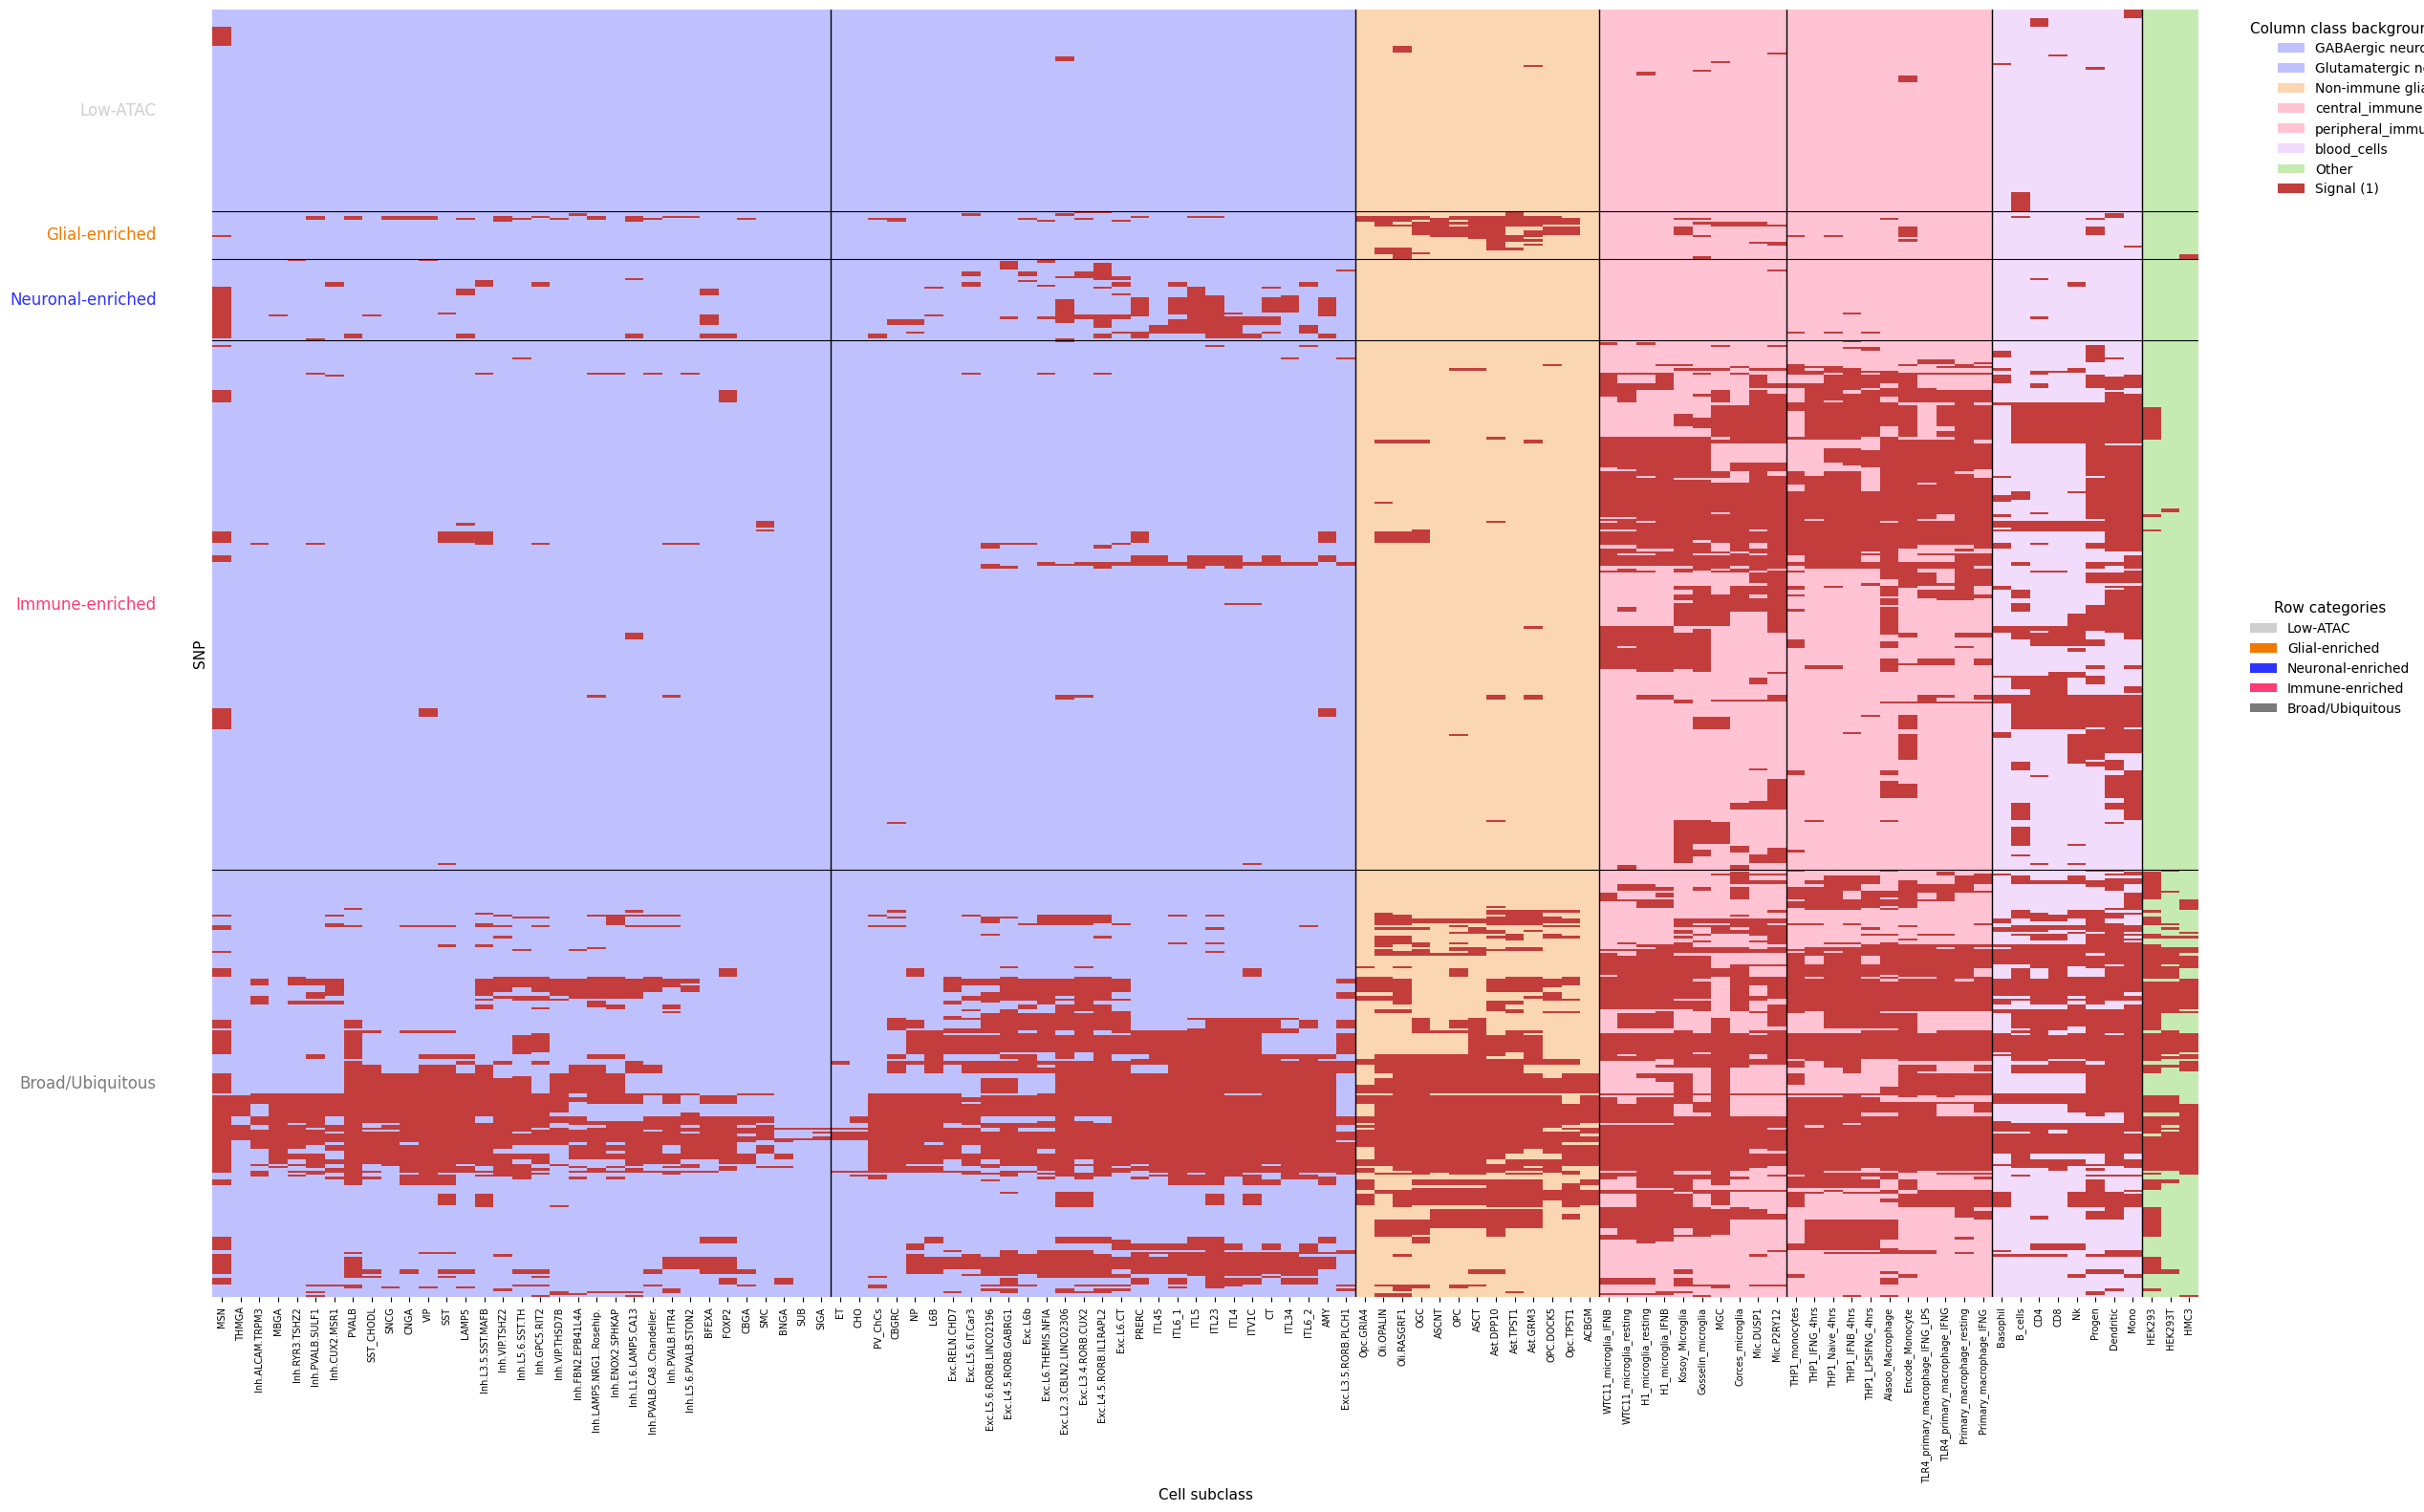

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, leaves_list
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

# =========================================================
# Make vector outputs Illustrator-friendly
# =========================================================
mpl.rcParams["pdf.fonttype"] = 42   # editable text in Illustrator
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["axes.linewidth"] = 0.8

# =========================================================
# CONFIG
# =========================================================
ROW_METRIC = "jaccard"
ROW_LINKAGE = "average"
COL_METRIC = "jaccard"
COL_LINKAGE = "average"

OTHER_ALIASES = {"Other", "other", "Unannotated", "unknown", "Unknown"}

# column background colors
CLASS_LUT = {
    "GABAergic neurons":     "#2D33FF",  # blue
    "Glutamatergic neurons": "#2D33FF",  # blue
    "Non-immune glia":       "#F07A00",  # orange
    "central_immune":        "#FF3B73",  # pink-red
    "peripheral_immune":     "#FF3B73",  # pink-red
    "blood_cells":           "#D38CF6",  # light purple
    "Other":                 "#43C000",  # green
}

BACKGROUND_ALPHA = 0.3
BOUNDARY_LW = 1.0
RED_COLOR = "#C33D3D"

# row category order
ROW_CAT_ORDER = [
    "Low-ATAC",
    "Glial-enriched",
    "Neuronal-enriched",
    "Immune-enriched",
    "Broad/Ubiquitous",
]

ROW_CAT_COLORS = {
    "Neuronal-enriched": "#2D33FF",
    "Glial-enriched": "#F07A00",
    "Immune-enriched": "#FF3B73",
    "Broad/Ubiquitous": "#7A7A7A",
    "Low-ATAC": "#CFCFCF",
}

# simple, intuitive thresholds
LOW_ATAC_MAX_TOTAL = 1
ACTIVE_CLASS_THRESHOLD = 0.10
BROAD_MIN_ACTIVE_CLASSES = 2
BROAD_MAX_TOP_FRACTION = 0.65

ENRICH_MIN_TOP_SCORE = 0.16
ENRICH_MIN_RATIO = 1.50
ENRICH_MIN_DIFF = 0.08

# =========================================================
# 0) Matrix (binary)
# =========================================================
X = df_mat_subclass.copy()
X = X.loc[:, X.sum(axis=0) != 0]   # drop all-zero columns
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)
X = (X != 0).astype(np.int8)

# =========================================================
# 1) subclass -> class
# =========================================================
col_to_class = (
    df_ann[["Cell subclass", "Cell class name"]]
    .dropna()
    .drop_duplicates(subset=["Cell subclass"])
    .assign(
        **{
            "Cell subclass": lambda d: d["Cell subclass"].astype(str).str.strip(),
            "Cell class name": lambda d: d["Cell class name"].astype(str).str.strip(),
        }
    )
    .set_index("Cell subclass")["Cell class name"]
)

X.columns = X.columns.astype(str).str.strip()

missing = sorted(set(X.columns) - set(col_to_class.index))
if missing:
    raise ValueError(
        f"Some X columns not found in df_ann mapping (n={len(missing)}): {missing[:20]}"
    )

col_class = col_to_class.reindex(X.columns).astype(str)

# class order from df_ann; force Other last
class_order = (
    df_ann["Cell class name"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)
others = [c for c in class_order if c in OTHER_ALIASES]
class_order = [c for c in class_order if c not in OTHER_ALIASES] + others

# =========================================================
# 2) HARD partition columns by class; cluster within each class
# =========================================================
col_order = []
class_blocks = []
start_idx = 0

for cls in class_order:
    cols_in_cls = [c for c in X.columns if col_class[c] == cls]
    if not cols_in_cls:
        continue

    if len(cols_in_cls) == 1:
        ordered = cols_in_cls
    else:
        M = X[cols_in_cls].T.values
        d = pdist(M, metric=COL_METRIC)
        if len(d) == 0:
            ordered = cols_in_cls
        else:
            Z = linkage(d, method=COL_LINKAGE, optimal_ordering=True)
            ordered = [cols_in_cls[i] for i in leaves_list(Z)]

    col_order.extend(ordered)
    end_idx = start_idx + len(ordered)
    class_blocks.append((cls, start_idx, end_idx))
    start_idx = end_idx

remain = [c for c in X.columns if c not in col_order]
if remain:
    col_order += remain
    class_blocks.append(("Other", start_idx, start_idx + len(remain)))

X_plot = X.loc[:, col_order]
col_class_plot = col_class.reindex(col_order)

# =========================================================
# 3) Row categorization: no "Other-enriched"
# =========================================================
class_hits = X_plot.T.groupby(col_class_plot).sum().T

for cls in class_order:
    if cls not in class_hits.columns:
        class_hits[cls] = 0

class_hits = class_hits.reindex(columns=[c for c in class_order if c in class_hits.columns])

class_sizes = col_class_plot.value_counts().reindex(class_hits.columns).fillna(0)
class_frac = class_hits.div(class_sizes.replace(0, np.nan), axis=1).fillna(0)

neuronal_cols = [c for c in ["GABAergic neurons", "Glutamatergic neurons"] if c in class_frac.columns]
immune_cols   = [c for c in ["central_immune", "peripheral_immune", "blood_cells"] if c in class_frac.columns]

neuronal_score = (
    class_frac[neuronal_cols].mean(axis=1)
    if neuronal_cols else pd.Series(0, index=class_frac.index)
)
immune_score = (
    class_frac[immune_cols].mean(axis=1)
    if immune_cols else pd.Series(0, index=class_frac.index)
)
glial_score = (
    class_frac["Non-immune glia"]
    if "Non-immune glia" in class_frac.columns else pd.Series(0, index=class_frac.index)
)
other_score = (
    class_frac["Other"]
    if "Other" in class_frac.columns else pd.Series(0, index=class_frac.index)
)

total_hits = class_hits.sum(axis=1)

# only these three are allowed to become "...-enriched"
combined_scores = pd.DataFrame({
    "Neuronal-enriched": neuronal_score,
    "Glial-enriched": glial_score,
    "Immune-enriched": immune_score,
}, index=X_plot.index).fillna(0)

# include Other only for deciding whether a row is broad
all_scores_for_broad = pd.DataFrame({
    "Neuronal-enriched": neuronal_score,
    "Glial-enriched": glial_score,
    "Immune-enriched": immune_score,
    "Other": other_score,
}, index=X_plot.index).fillna(0)

def assign_row_category(idx):
    total = total_hits.loc[idx]

    # only these can become enriched labels
    scores = combined_scores.loc[idx].sort_values(ascending=False)

    # Other contributes only to broadness
    broad_scores = all_scores_for_broad.loc[idx]

    if total <= LOW_ATAC_MAX_TOTAL:
        return "Low-ATAC"

    top_label = scores.index[0]
    top_val = float(scores.iloc[0])
    second_val = float(scores.iloc[1]) if len(scores) > 1 else 0.0

    broad_score_sum = float(broad_scores.sum())
    if broad_score_sum <= 0:
        return "Low-ATAC"

    top_fraction = top_val / broad_score_sum
    n_active = int((broad_scores >= ACTIVE_CLASS_THRESHOLD).sum())

    if n_active >= BROAD_MIN_ACTIVE_CLASSES and top_fraction <= BROAD_MAX_TOP_FRACTION:
        return "Broad/Ubiquitous"

    if top_val >= ENRICH_MIN_TOP_SCORE:
        ratio_ok = (second_val == 0) or (top_val / second_val >= ENRICH_MIN_RATIO)
        diff_ok = (top_val - second_val) >= ENRICH_MIN_DIFF
        if ratio_ok or diff_ok:
            return top_label

    if n_active >= BROAD_MIN_ACTIVE_CLASSES:
        return "Broad/Ubiquitous"

    return top_label

row_category = pd.Series(
    [assign_row_category(idx) for idx in X_plot.index],
    index=X_plot.index,
    name="row_category"
)

# =========================================================
# 4) Order rows: hard partition by row_category, cluster within each group
# =========================================================
row_order = []
row_boundaries = []

for gname in ROW_CAT_ORDER:
    idx = row_category[row_category == gname].index.tolist()
    if not idx:
        continue

    if len(idx) == 1:
        ordered_idx = idx
    else:
        M = X_plot.loc[idx].values
        d = pdist(M, metric=ROW_METRIC)
        if len(d) == 0:
            ordered_idx = idx
        else:
            Z = linkage(d, method=ROW_LINKAGE, optimal_ordering=True)
            ordered_idx = [idx[i] for i in leaves_list(Z)]

    row_order.extend(ordered_idx)
    row_boundaries.append(len(row_order))

remain_rows = [r for r in X_plot.index if r not in row_order]
row_order += remain_rows

X_plot2 = X_plot.loc[row_order]
row_category_plot = row_category.reindex(row_order)

# only draw 1s; keep 0 transparent
X_ones = X_plot2.astype(float).copy()
X_ones[X_ones == 0] = np.nan

# =========================================================
# 5) Plot
# =========================================================
FIG_W = max(20, 0.28 * X_plot2.shape[1])
FIG_H = max(10, 0.03 * X_plot2.shape[0])

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

# column-class background blocks
for cls, start, end in class_blocks:
    color = CLASS_LUT.get(cls, "#DDDDDD")
    ax.axvspan(
        start,
        end,
        ymin=0,
        ymax=1,
        facecolor=color,
        alpha=BACKGROUND_ALPHA,
        edgecolor="none",
        zorder=0
    )

# red-only heatmap
cmap_red_only = ListedColormap([RED_COLOR])
cmap_red_only.set_bad((1, 1, 1, 0))

sns.heatmap(
    X_ones,
    ax=ax,
    cmap=cmap_red_only,
    vmin=1,
    vmax=1,
    cbar=False,
    xticklabels=True,
    yticklabels=False,
    linewidths=0,
    linecolor=None
)

ax.set_xlim(0, X_plot2.shape[1])
ax.set_ylim(X_plot2.shape[0], 0)

# vertical class boundaries
for _, _, end in class_blocks[:-1]:
    ax.axvline(end, color="black", lw=BOUNDARY_LW, zorder=5)

# horizontal row-category boundaries
for y in row_boundaries[:-1]:
    if y < X_plot2.shape[0]:
        ax.axhline(y, color="black", lw=0.8, zorder=5)

# labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=7)
ax.set_xlabel("Cell subclass", fontsize=11)
ax.set_ylabel("SNP", fontsize=11)

# row-category labels on left
present_row_cats = [g for g in ROW_CAT_ORDER if (row_category_plot == g).any()]
row_cat_ranges = []
start = 0
for g in present_row_cats:
    n = int((row_category_plot == g).sum())
    if n > 0:
        row_cat_ranges.append((g, start, start + n))
        start += n

x_text = -max(3, X_plot2.shape[1] * 0.015)
for g, s, e in row_cat_ranges:
    y_mid = (s + e) / 2
    ax.text(
        x_text,
        y_mid,
        g,
        color=ROW_CAT_COLORS.get(g, "black"),
        fontsize=12,
        ha="right",
        va="center",
        clip_on=False
    )

# legends
col_classes_present = [cls for cls, _, _ in class_blocks]
col_classes_present = list(dict.fromkeys(col_classes_present))

handles_bg = [
    Patch(
        facecolor=CLASS_LUT.get(c, "#DDDDDD"),
        edgecolor="none",
        alpha=BACKGROUND_ALPHA,
        label=c
    )
    for c in col_classes_present
]
handles_bg.append(Patch(facecolor=RED_COLOR, edgecolor="none", label="Signal (1)"))

leg1 = ax.legend(
    handles=handles_bg,
    title="Column class background / signal",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    frameon=False,
    fontsize=10,
    title_fontsize=11
)
ax.add_artist(leg1)

handles_row = [
    Patch(facecolor=ROW_CAT_COLORS[g], edgecolor="none", label=g)
    for g in present_row_cats
]
ax.legend(
    handles=handles_row,
    title="Row categories",
    bbox_to_anchor=(1.02, 0.55),
    loc="upper left",
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

plt.subplots_adjust(left=0.12, right=0.82, top=0.97, bottom=0.22)

base = f"SNPs_heatmap_noOtherEnriched_ubiquitousFirst_{ROW_METRIC}-{ROW_LINKAGE}"
out_pdf = f"{base}.pdf"
out_svg = f"{base}.svg"
out_png = f"{base}.png"

# vector outputs
fig.savefig(out_pdf, bbox_inches="tight")
fig.savefig(out_svg, bbox_inches="tight")

# high-resolution raster output
fig.savefig(out_png, dpi=600, bbox_inches="tight")

print("Saved:", out_pdf, out_svg, out_png)
print("\nRow category counts:")
print(row_category.value_counts().reindex(ROW_CAT_ORDER).dropna())
print("\nClass sizes:")
print(class_sizes)

In [4]:
import pandas as pd

# =========================================================
# 6) Add row_category to annotation CSV by rsID
#    row_category's index is already rsID
# =========================================================
csv_path = "indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_with_all_peakfiles_variant_category_20260310_Bellenguez_AD_direction.csv"

meta = pd.read_csv(csv_path)

# rsID column of the annotation csv
meta["rsID"] = meta["rsID"].astype(str).str.strip()

# row_category's index is rsID
row_category_df = (
    row_category.rename("Variant_Category")
    .rename_axis("rsID")
    .reset_index()
)

row_category_df["rsID"] = row_category_df["rsID"].astype(str).str.strip()

# normalize the label used in the figure to "Broad"
row_category_df["Variant_Category"] = row_category_df["Variant_Category"].replace({
    "Broad/Ubiquitous": "Broad"
})

# drop duplicate rsIDs first, if any
row_category_df = row_category_df.drop_duplicates(subset=["rsID"], keep="first")

# merge row_category into the annotation table
meta_out = meta.merge(
    row_category_df,
    on="rsID",
    how="left"
)

# check merge coverage
n_matched = meta_out["Variant_Category"].notna().sum()
n_missing = meta_out["Variant_Category"].isna().sum()

print(f"Matched rows: {n_matched} / {len(meta_out)}")
print(f"Unmatched rows: {n_missing} / {len(meta_out)}")

if n_missing > 0:
    print("\nExample unmatched rsIDs:")
    print(meta_out.loc[meta_out["Variant_Category"].isna(), ["rsID"]].head(20))

# save the annotated table
out_csv = csv_path.replace("20260112.csv", "variant_category_20260310.csv")
meta_out.to_csv(out_csv, index=False)

print("Saved:", out_csv)

Matched rows: 855 / 855
Unmatched rows: 0 / 855
Saved: indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_with_all_peakfiles_variant_category_20260310.csv


In [ ]:
cd "/media/zihengc/T7/atac/jaccard_index/raw_peaks_uncompressed_20260112"
mkdir -p premerged

# parallel pre-merge of bed / narrowPeak / txt peak files
find . -maxdepth 1 -type f \
  \( -name "*.bed" -o -name "*.narrowPeak" -o -name "*.txt" \) \
  ! -name "*.csv" ! -name "*.tsv" \
  -print0 \
| xargs -0 -n 1 -P 12 bash -lc '
  f="$1"
  bn="$(basename "$f")"

  awk '\''BEGIN{OFS="\t"} {print $1,$2,$3}'\'' "$f" \
    | awk '\''BEGIN{OFS="\t"} $1!="" && $2~/^[0-9]+$/ && $3~/^[0-9]+$/ && $3>$2 {print $1,$2,$3}'\'' \
    | LC_ALL=C sort -k1,1 -k2,2n \
    | bedtools merge -i - \
    > "premerged/$bn"

  # if empty after filtering (not bed-like, or all invalid lines), remove it to avoid accidental downstream use
  if [ ! -s "premerged/$bn" ]; then
    rm -f "premerged/$bn"
  fi
' _

python jaccard_subclass_premerged.py \
  --premerged_dir "/media/zihengc/T7/atac/jaccard_index/raw_peaks_uncompressed_20260112/premerged" \
  --metadata_csv "catlas_cCREs/metadata/bed_annotation_with_immune_added_brainpeaks.csv" \
  --group_col "Cell subclass" \
  --out_prefix "jaccard_subclass_premerged" \
  --threads 12


['BFEXA',
 'BNGA',
 'CBGA',
 'CNGA',
 'FOXP2',
 'LAMP5',
 'MBGA',
 'MSN',
 'PVALB',
 'SIGA',
 'SMC',
 'SNCG',
 'SST',
 'SST_CHODL',
 'SUB',
 'THMGA',
 'VIP',
 'AMY',
 'CBGRC',
 'CHO',
 'CT',
 'ET',
 'ITL23',
 'ITL34',
 'ITL4',
 'ITL45',
 'ITL5',
 'ITL6_1',
 'ITL6_2',
 'ITV1C',
 'L6B',
 'NP',
 'PRERC',
 'PV_ChCs',
 'ACBGM',
 'ASCNT',
 'ASCT',
 'MGC',
 'OGC',
 'OPC',
 'Corces_Microglia_sgATAC_hg38.idr.optimal.narrowPeak',
 'Gosselin_Microglia_ATAC_hg38.idr.optimal_peak.narrowPeak',
 'H1resting.idr.optimal_peak.narrowPeak',
 'H1stimulated.idr.optimal_peak.narrowPeak',
 'HMC3.idr.optimal_peak.narrowPeak',
 'Kosoy_Microglia_OCRs_hg38.bed',
 'Mic.DUSP1.peak.annotation.txt',
 'Mic.P2RY12.peak.annotation.txt',
 'WTC11resting.idr.optimal_peak.narrowPeak',
 'WTC11stimulated.idr.optimal_peak.narrowPeak',
 'HEK293T_ATAC.idr.conservative_peak.narrowPeak',
 'HEK293_ATAC_high_depth.idr.conservative_peak.narrowPeak',
 'Alasoo_Macrophage_ATAC_hg38.bed',
 'Encode_Monocyte_DHS_hg38.narrowPeak',
 'M2_IFNG

[WARN] In SNP clustermap order but missing in Jaccard (n=0):
[] 
[INFO] In Jaccard but not in SNP clustermap order (n=2):
['EC', 'PER'] 


C:\Users\da111\AppData\Local\Temp\ipykernel_32660\2846397834.py:83: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


Saved: Jaccard_heatmap_matched_to_SNPorder.png Jaccard_heatmap_matched_to_SNPorder.pdf


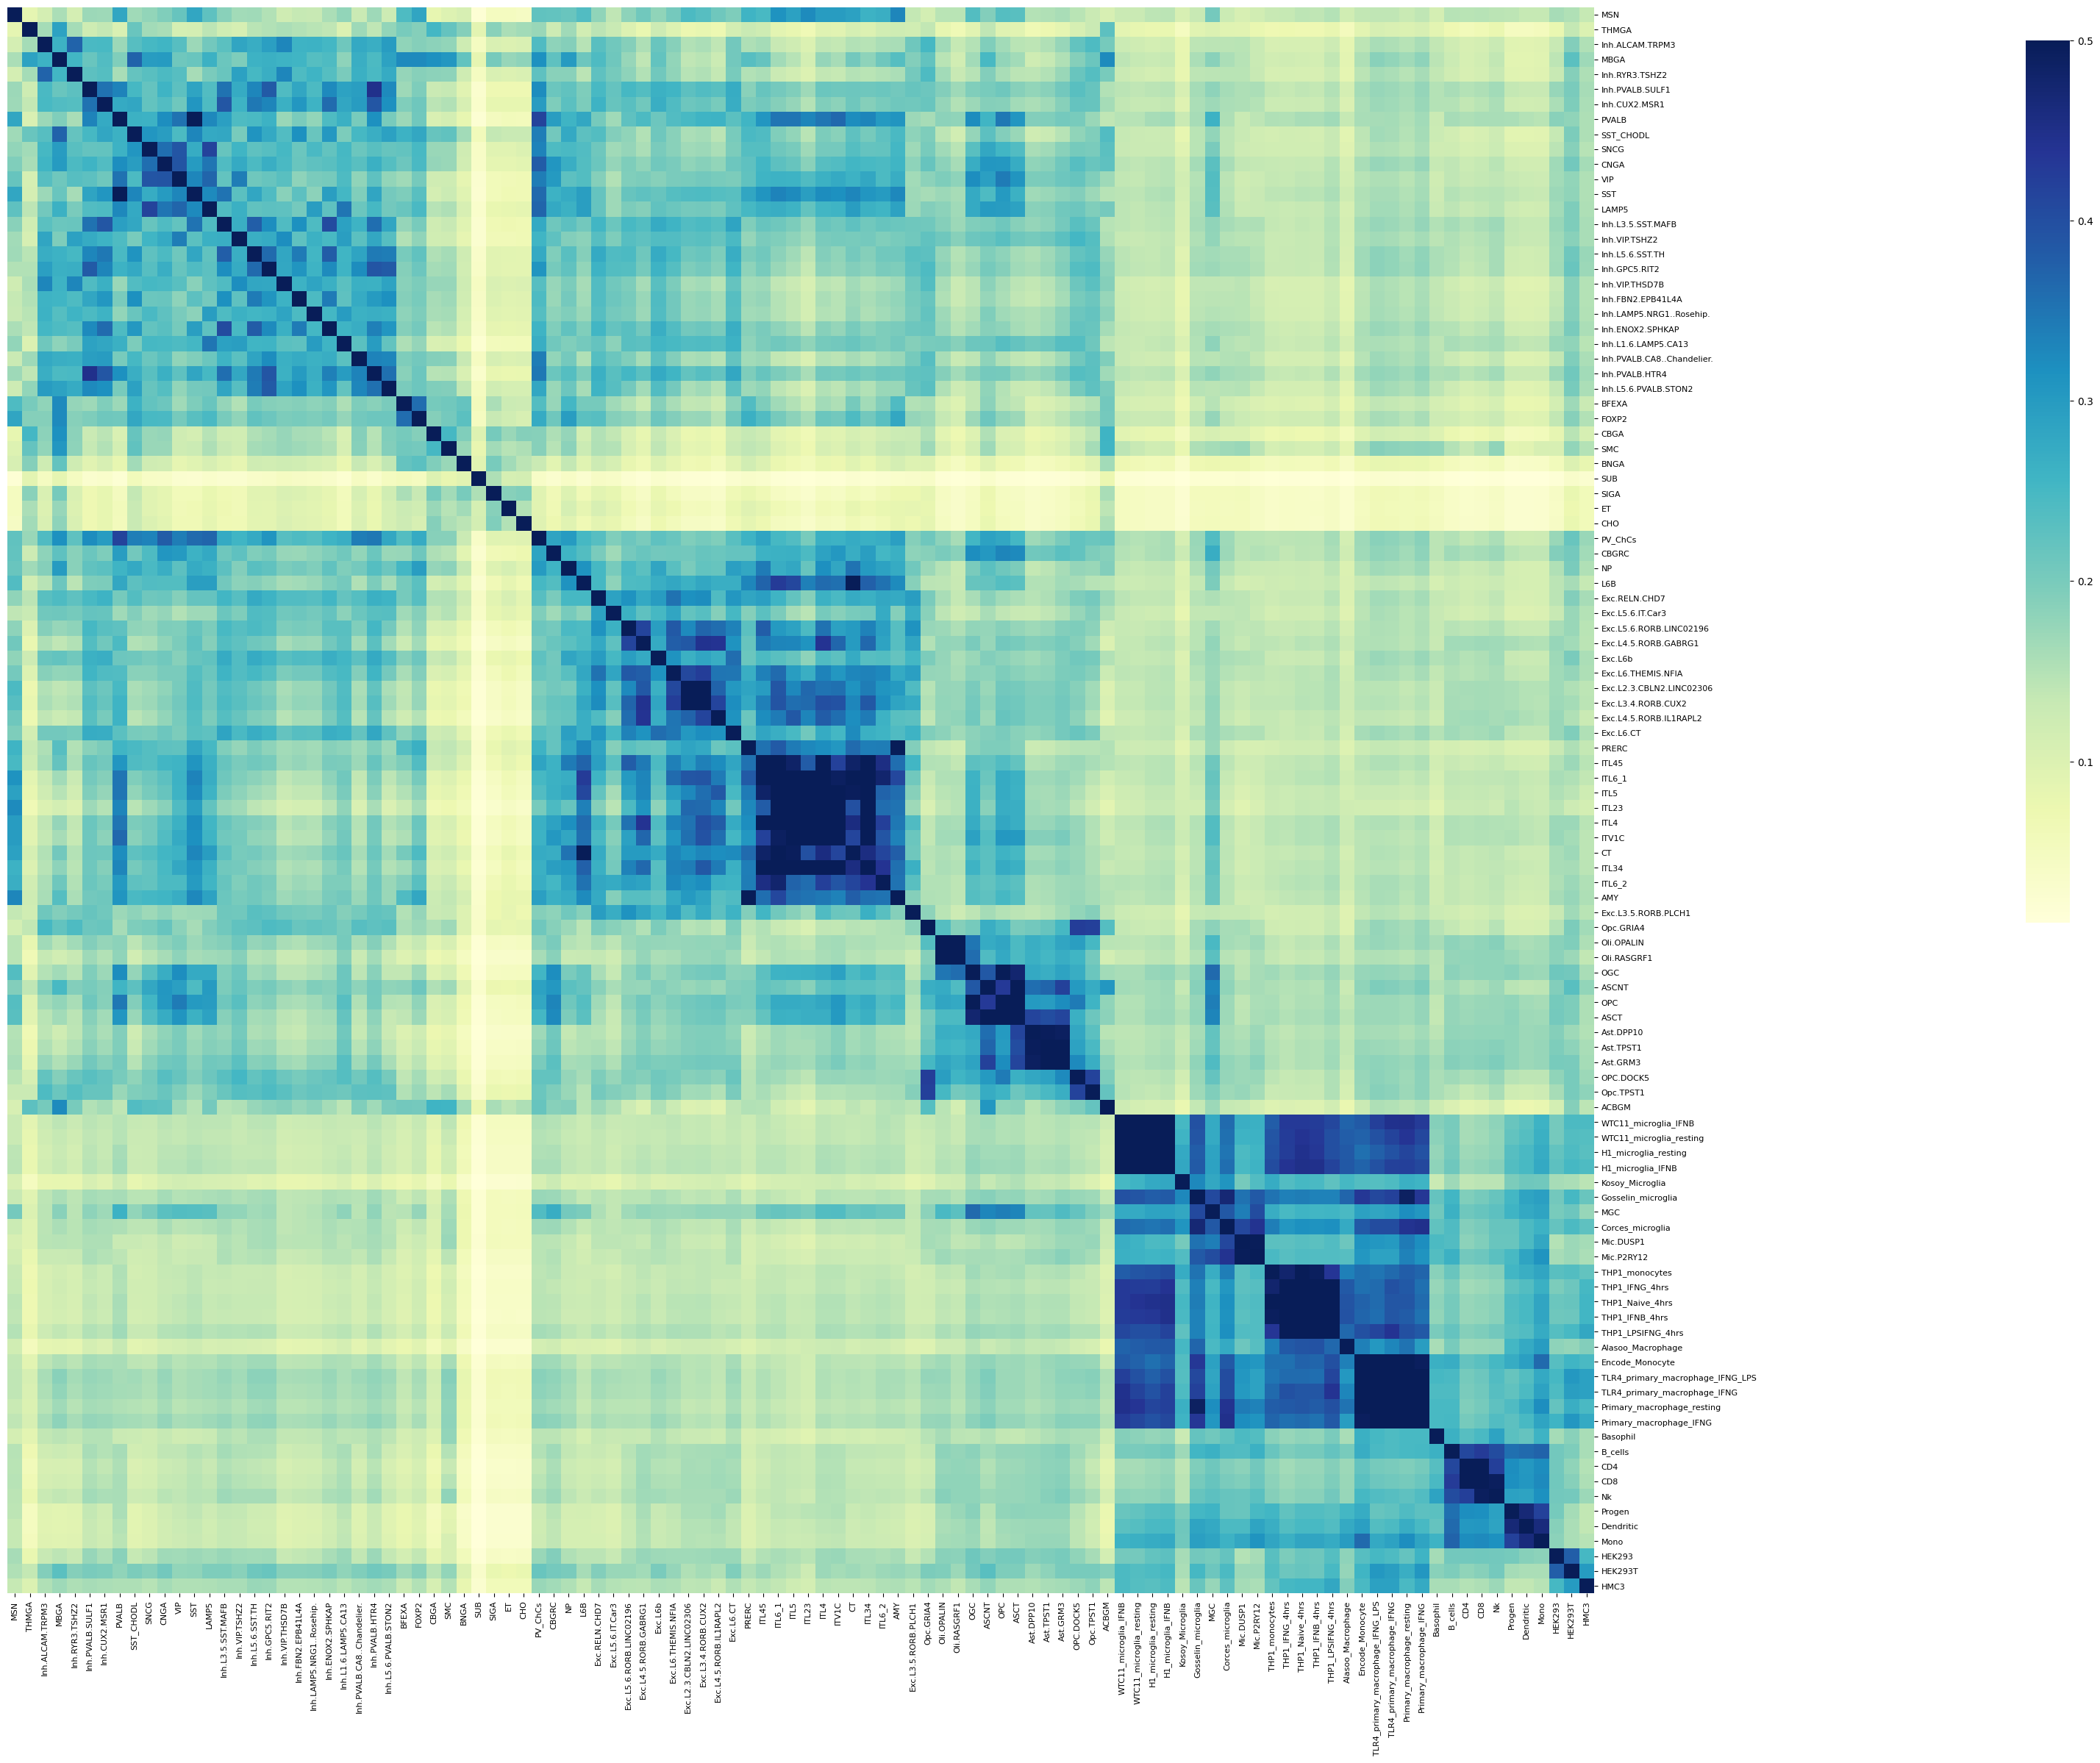

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ========= 0) Final column order from the earlier SNP clustermap =========
subclass_order = X_plot2.columns.astype(str).tolist()

# ========= 1) load Jaccard matrix =========
jaccard_df = pd.read_csv(
    '../atac/jaccard_index/raw_peaks_uncompressed_20260112/jaccard_subclass_premerged.jaccard_matrix.csv',
    index_col=0
)
jaccard_df.index = jaccard_df.index.astype(str)
jaccard_df.columns = jaccard_df.columns.astype(str)

# ========= 2) Clean up peak-file names =========
def clean_name(s: str) -> str:
    s = str(s)
    for old in [
        ".idr.optimal_peak.narrowPeak",
        ".peak.annotation.txt",
        ".idr.conservative_peak.narrowPeak",
        ".idr.conservative_peak",
        ".idr.optimal",
        ".narrowPeak",
        ".txt",
        ".bed",
        "_hg38",
    ]:
        s = s.replace(old, "")
    return s

jaccard_df.index = [clean_name(x) for x in jaccard_df.index]
jaccard_df.columns = [clean_name(x) for x in jaccard_df.columns]
subclass_order = [clean_name(x) for x in subclass_order]

# ========= 3) Report mismatches =========
missing_in_j = [c for c in subclass_order if c not in set(jaccard_df.index)]
extra_in_j   = [c for c in jaccard_df.index if c not in set(subclass_order)]

print(f"[WARN] In SNP clustermap order but missing in Jaccard (n={len(missing_in_j)}):")
print(missing_in_j[:80], "..." if len(missing_in_j) > 80 else "")
print(f"[INFO] In Jaccard but not in SNP clustermap order (n={len(extra_in_j)}):")
print(extra_in_j[:80], "..." if len(extra_in_j) > 80 else "")

# ========= 4) Align row/column order =========
J_plot = jaccard_df.reindex(index=subclass_order, columns=subclass_order)
mask = J_plot.isna()

# ========= 5) Plot =========
exclude_list = []
if exclude_list:
    J_plot = J_plot.drop(exclude_list, errors="ignore").drop(exclude_list, axis=1, errors="ignore")
    mask = J_plot.isna()

g = sns.clustermap(
    J_plot,
    cmap="YlGnBu",
    annot=False,
    fmt=".2f",
    linewidths=0,          # remove cell gridlines
    linecolor=None,        # optional: further avoid boundary lines
    cbar_pos=(0.05, 0.85, 0.05, 0.1),
    vmax=0.5,
    figsize=(30, 30),
    method="average",
    row_cluster=False,
    col_cluster=False,
    mask=mask,
)

g.cax.set_visible(True)
g.cax.set_position([1.1, 0.4, 0.02, 0.4])

if hasattr(g, "ax_row_dendrogram") and g.ax_row_dendrogram is not None:
    g.ax_row_dendrogram.set_visible(False)
if hasattr(g, "ax_col_dendrogram") and g.ax_col_dendrogram is not None:
    g.ax_col_dendrogram.set_visible(False)

plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=8, rotation=90)
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=8, rotation=0)

plt.tight_layout()

out_png = "Jaccard_heatmap_matched_to_SNPorder.png"
out_pdf = "Jaccard_heatmap_matched_to_SNPorder.pdf"
g.savefig(out_png, dpi=300)
g.savefig(out_pdf, dpi=300)
print("Saved:", out_png, out_pdf)